In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)
import sys
# sys.path.append(r"E:\Python code\Machine learning\JupyterNote\Bio_CRC\Data processing\functions")
sys.path.append(r"/ihome/ylee/yiz133/Code/Data processing/functions/")
import mdata_utils 
import TCR_embedings

2026-05-18 21:22:38.672781: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-18 21:22:38.697132: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-18 21:22:39.413919: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-18 21:22:45.054613: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
from sklearn.preprocessing import StandardScaler
from scipy.sparse import issparse

In [3]:
path = r"/ix1/ylee/Yifan_Zhang/Code_data/Tumor/GSE139555_2019/data/Processed/"
filename = "T_DE_per_sample_TCRemb.h5mu"
DATA_PATH = path + filename

mdata_ori = mu.read(DATA_PATH)

In [4]:
mdata = mdata_ori.copy()
mdata

MuData object with n_obs × n_vars = 51775 × 2551
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned', 'in_two_tissue', 'clone_status', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length'
  uns:	'hvg_union_COMBAT_ID_meta', 'tcr_embs_feature_names'
  obsm:	'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call', 'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	51775 x 2551
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'patient', 'source', 'type', 'subtype', 'clone_status'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'hvg_union_COMBAT_ID', 'mean', 'std'
      uns:	'X_umap_harmony', 'hvg_union_COMBAT_ID_k200', 'hvg_union_COMBAT_ID_meta', 'log1p', 'neighbors', 'neighbors_harmony', 'patient_colors', 'pca', 'source_colors', 'subtype_colors', 'type_colors', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'
    airr:	51775 x 0
      obs:	'sample', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'cc_aa_tcrdist', 'chain_indices', 'clone_id', 'ir_dist_aa_identity', 'ir_dist_aa_tcrdist', 'ir_dist_nt_identity'
      obsm:	'airr', 'chain_indices'

In [45]:
mdata['gex'].obs['subtype'].value_counts()

subtype
CD4_TCF7         6277
CD4_FOS          4173
CD4_Treg         3412
CD4_Trm          2595
CD8_Tem          1849
CD8_Trm_exh_L    1798
CD4_RPL32        1749
CD4_IL6ST        1696
others_MT        1050
CD8_Trm_exh_H     943
CD8_Teff          774
CD8_Trm_exh_M     655
CD8_KLRB1         440
CD8_Chrom         292
CD8_Mitosis       278
others_nan         21
Name: count, dtype: int64

In [6]:
#### subset on patient
# k = 10
# selected = np.random.choice(
#     mdata['gex'].obs['COMBAT_ID'].value_counts().index,
#     size=k,
#     replace=False
# ).tolist()
# mask = mdata['gex'].obs['COMBAT_ID'].isin(selected)
# mdata = mdata[mask].copy()


#### subset on disease
# mdata = mdata[mdata.obs['source'].isin(['Blood', 'NAT'])]
# mdata = mdata[mdata.obs['source'].isin(['Tumor'])]

mdata = mdata[~mdata['gex'].obs['subtype'].isin(['others_nan', 'others_MT'])]

mdata

MuData object with n_obs × n_vars = 51775 × 2551
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned', 'in_two_tissue', 'clone_status', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length'
  uns:	'hvg_union_COMBAT_ID_meta', 'tcr_embs_feature_names'
  obsm:	'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call', 'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	51775 x 2551
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'patient', 'source', 'type', 'subtype', 'clone_status'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'hvg_union_COMBAT_ID', 'mean', 'std'
      uns:	'X_umap_harmony', 'hvg_union_COMBAT_ID_k200', 'hvg_union_COMBAT_ID_meta', 'log1p', 'neighbors', 'neighbors_harmony', 'patient_colors', 'pca', 'source_colors', 'subtype_colors', 'type_colors', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'
    airr:	51775 x 0
      obs:	'sample', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'cc_aa_tcrdist', 'chain_indices', 'clone_id', 'ir_dist_aa_identity', 'ir_dist_aa_tcrdist', 'ir_dist_nt_identity'
      obsm:	'airr', 'chain_indices'

In [7]:
# subseting on single pair
# mdata = mdata[mdata['airr'].obs['chain_pairing'].isin(['single pair'])]
# mdata = mdata[mdata['gex'].obs['COMBAT_ID'].astype(int) > 20]

# mdata = mdata_utils.sync_mdata_obs(mdata)
mdata

MuData object with n_obs × n_vars = 51775 × 2551
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned', 'in_two_tissue', 'clone_status', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length'
  uns:	'hvg_union_COMBAT_ID_meta', 'tcr_embs_feature_names'
  obsm:	'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call', 'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	51775 x 2551
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'patient', 'source', 'type', 'subtype', 'clone_status'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'hvg_union_COMBAT_ID', 'mean', 'std'
      uns:	'X_umap_harmony', 'hvg_union_COMBAT_ID_k200', 'hvg_union_COMBAT_ID_meta', 'log1p', 'neighbors', 'neighbors_harmony', 'patient_colors', 'pca', 'source_colors', 'subtype_colors', 'type_colors', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'
    airr:	51775 x 0
      obs:	'sample', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'cc_aa_tcrdist', 'chain_indices', 'clone_id', 'ir_dist_aa_identity', 'ir_dist_aa_tcrdist', 'ir_dist_nt_identity'
      obsm:	'airr', 'chain_indices'

In [8]:
## select one cell from each clonotype

airr_obs = mdata['airr'].obs.copy()
clone_id_col = airr_obs['clone_id']
if hasattr(clone_id_col, 'cat'):
    clone_id_col = clone_id_col.astype(str)
airr_obs['_clone_id_str'] = clone_id_col

expanded = airr_obs[airr_obs['clone_id_size'] > 1].dropna(subset=['_clone_id_str'])
sampled_expanded_idx = (
    expanded
    .groupby('_clone_id_str', observed=True)
    .sample(n=1, random_state=42)
    .index
)

single_idx = airr_obs[airr_obs['clone_id_size'] == 1].index
keep_idx = sampled_expanded_idx.append(single_idx)

mdata = mdata[keep_idx].copy()
print(f"Expanded clones: {len(expanded)} cells -> {len(sampled_expanded_idx)} (1 per clone)")
print(f"Single clones: {len(single_idx)}")
print(f"Total after dedup: {mdata.n_obs} cells")


Expanded clones: 28178 cells -> 4405 (1 per clone)
Single clones: 23597
Total after dedup: 28002 cells


In [9]:
tcr_embs = mdata.obsm['tcr_embs']

#### no subsetteing  ####
view_gene = mdata['gex'].X
# view_gene = gex.X.toarray()

view_gene = np.asarray(view_gene, dtype=float)
view_tcr = np.asarray(tcr_embs, dtype=float)

scaler = StandardScaler()
# view_gene = scaler.fit_transform(view_gene)
# view_tcr = scaler.fit_transform(view_tcr)

from sklearn.decomposition import PCA
pca_gene = PCA(n_components=50, random_state=42)
view_gene_pca = pca_gene.fit_transform(view_gene)
var_explained = pca_gene.explained_variance_ratio_
view_gene = view_gene_pca

# print("GEX variance explained:", var_explained.cumsum())

In [10]:
# Check what view_gene actually contains
print("Mean expression:", view_gene.mean())
print("Max expression:", view_gene.max())
print("Sparsity:", (view_gene == 0).sum() / view_gene.size)

# Check variance per gene
gene_var = view_gene.var(axis=0)
print("Genes with near-zero variance:", (gene_var < 0.01).sum())
print("Variance distribution:")
print(np.percentile(gene_var, [25, 50, 75, 90, 95, 99]))

Mean expression: -4.109972843452123e-15
Max expression: 45.711155144821795
Sparsity: 0.0
Genes with near-zero variance: 0
Variance distribution:
[ 1.31524083  1.50254606  2.18599604  4.17864236  7.72046889 11.23668222]


In [11]:
gex = mdata['gex']

# Check raw counts characteristics
import numpy as np

X = gex.X
if hasattr(X, 'toarray'):
    vals = X.toarray()
else:
    vals = np.asarray(X)

print("Min value:", vals.min())
print("Max value:", vals.max())
print("Mean value:", vals.mean())
print("Has non-integer values:", not np.all(vals == vals.astype(int)))
print("Sparsity:", (vals == 0).mean())

Min value: -1.8877615294622172
Max value: 10.0
Mean value: -0.019865263523509896
Has non-integer values: True
Sparsity: 0.0


In [12]:
# # ── TCR side (optional) ──────────────────────────────────────────────
# pca_tcr = PCA(n_components=20, random_state=42)  # or keep all 244
# view_tcr_pca = pca_tcr.fit_transform(view_tcr)
# var_explained_tcr = pca_tcr.explained_variance_ratio_
# print("TCR variance explained:", var_explained_tcr.cumsum())


print(f"view_gene: {view_gene.shape} ")
print(f"view_tcr:  {view_tcr.shape}  ")

view_gene: (28002, 50) 
view_tcr:  (28002, 405)  


## CCA

In [13]:
### Train / test split + dataloaders ###
from sklearn.model_selection import train_test_split
mdata.obs['set'] = ''

train_frac = 0.7
dim_cca = min(view_gene.shape[1], view_tcr.shape[1], 5)

train_mask = np.random.rand(mdata.n_obs) < train_frac
test_mask = ~train_mask
mdata.obs.loc[train_mask, 'set'] = 'train'
mdata.obs.loc[test_mask, 'set'] = 'test'

view_gene_train = view_gene[train_mask]
view_gene_test = view_gene[test_mask]
view_tcr_train = view_tcr[train_mask]
view_tcr_test = view_tcr[test_mask]

print(f"Train: {view_gene_train.shape[0]}  Test: {view_gene_test.shape[0]}")
print(f"Latent dims (dim_cca): {dim_cca}")

Train: 19628  Test: 8374
Latent dims (dim_cca): 5


In [14]:
### Deep CCA: fit ###
sys.path.append(r"/ihome/ylee/yiz133/Code/Tools/")

# from cca_zoo.deep import DCCA, architectures
# from cca_zoo.deep.data import NumpyDataset, check_dataset, get_dataloaders
# import lightning.pytorch as pl

# LATENT_DIMS = dim_cca
# EPOCHS = 30
# BATCH_SIZE = 64

# train_dataset = NumpyDataset([view_gene_train, view_tcr_train])
# test_dataset = NumpyDataset([view_gene_test, view_tcr_test])

# train_loader = get_dataloaders(train_dataset, batch_size=BATCH_SIZE)
# test_loader = get_dataloaders(test_dataset, batch_size=BATCH_SIZE)

# encoder_1 = architectures.Encoder(
#     latent_dimensions=LATENT_DIMS, feature_size=view_gene_train.shape[1],
# )
# encoder_2 = architectures.Encoder(
#     latent_dimensions=LATENT_DIMS, feature_size=view_tcr_train.shape[1],
# )

# dcca = DCCA(latent_dimensions=LATENT_DIMS, encoders=[encoder_1, encoder_2])
# trainer = pl.Trainer(
#     max_epochs=EPOCHS,
#     enable_checkpointing=True,
#     enable_model_summary=True,
#     enable_progress_bar=True,
# )
# trainer.fit(dcca, train_loader)

# from torch.utils.data import DataLoader
# train_loader_full = DataLoader(NumpyDataset([view_gene_train, view_tcr_train]), batch_size=BATCH_SIZE, drop_last=False, shuffle=False)
# test_loader_full = DataLoader(NumpyDataset([view_gene_test, view_tcr_test]), batch_size=BATCH_SIZE, drop_last=False, shuffle=False)
# view_gene_c_train, view_tcr_c_train = cca.transform(train_loader_full)
# view_gene_c_test, view_tcr_c_test = cca.transform(test_loader_full)

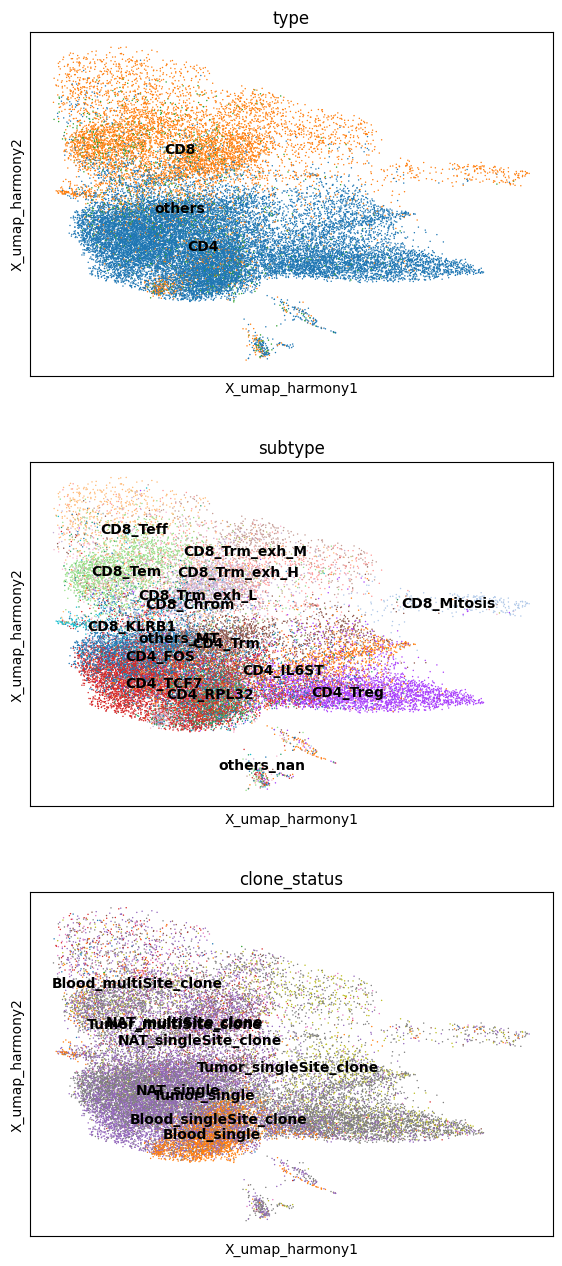

In [15]:
cols = [c for c in (
    'type',
    'subtype','cloned', 'in_two_tissue', 'clone_status'
) if c in mdata['gex'].obs]

sc.pl.embedding(mdata['gex'], basis = 'X_umap_harmony', neighbors_key = 'neighbors_harmony', legend_loc='on data',
                color=cols, ncols=1, )


In [16]:
# self CCA
dim_cca = 4
# cca = TCR_embedings.CCA(n_components=dim_cca) 
cca = TCR_embedings.rCCA(n_components=dim_cca, alpha_x=5, alpha_y=5,)

view_gene_c_train, view_tcr_c_train = cca.fit_transform(view_gene_train, view_tcr_train)
view_gene_c_test, view_tcr_c_test = cca.transform(view_gene_test, view_tcr_test)

In [17]:
# Standardise canonical variates
        
# view_gene_c_train = scaler.fit_transform(view_gene_c_train)
# view_tcr_c_train = scaler.fit_transform(view_tcr_c_train)
# view_gene_c_test = scaler.fit_transform(view_gene_c_test)
# view_tcr_c_test = scaler.fit_transform(view_tcr_c_test)

# Combine into full-dataset arrays
view_gene_c = np.zeros((mdata.n_obs, dim_cca))
view_tcr_c = np.zeros((mdata.n_obs, dim_cca))
view_gene_c[train_mask] = view_gene_c_train
view_gene_c[test_mask] = view_gene_c_test
view_tcr_c[train_mask] = view_tcr_c_train
view_tcr_c[test_mask] = view_tcr_c_test

# Store canonical variate scores in mdata
for i in range(dim_cca):
    mdata['gex'].obs[f'DCCA_CV_{i}'] = view_gene_c[:, i]
    mdata['gex'].obs[f'DCCA_CV_TCR_{i}'] = view_tcr_c[:, i]

cv_list = []
for i in range(view_gene_c_train.shape[1]):
    mdata['gex'].obs['CV_score_'+str(i)] = view_tcr_c[:, i]
    cv_list.append('CV_score_'+str(i))
    
# Per-component correlations
print("Per-component correlations (train / test):")
for i in range(dim_cca):
    r_tr = np.corrcoef(view_gene_c_train[:, i], view_tcr_c_train[:, i])[0, 1]
    r_te = np.corrcoef(view_gene_c_test[:, i], view_tcr_c_test[:, i])[0, 1]
    print(f"  CC {i}: train {r_tr:.4f}  test {r_te:.4f}")

print(f"\nTrain canonical variates shape: {view_gene_c_train.shape}")
print(f"Test canonical variates shape:  {view_gene_c_test.shape}")

Per-component correlations (train / test):
  CC 0: train 0.3502  test 0.3095
  CC 1: train 0.2988  test 0.2785
  CC 2: train 0.1658  test 0.1085
  CC 3: train 0.1691  test 0.0837

Train canonical variates shape: (19628, 4)
Test canonical variates shape:  (8374, 4)


In [18]:
view_gene_c_test.shape

(8374, 4)

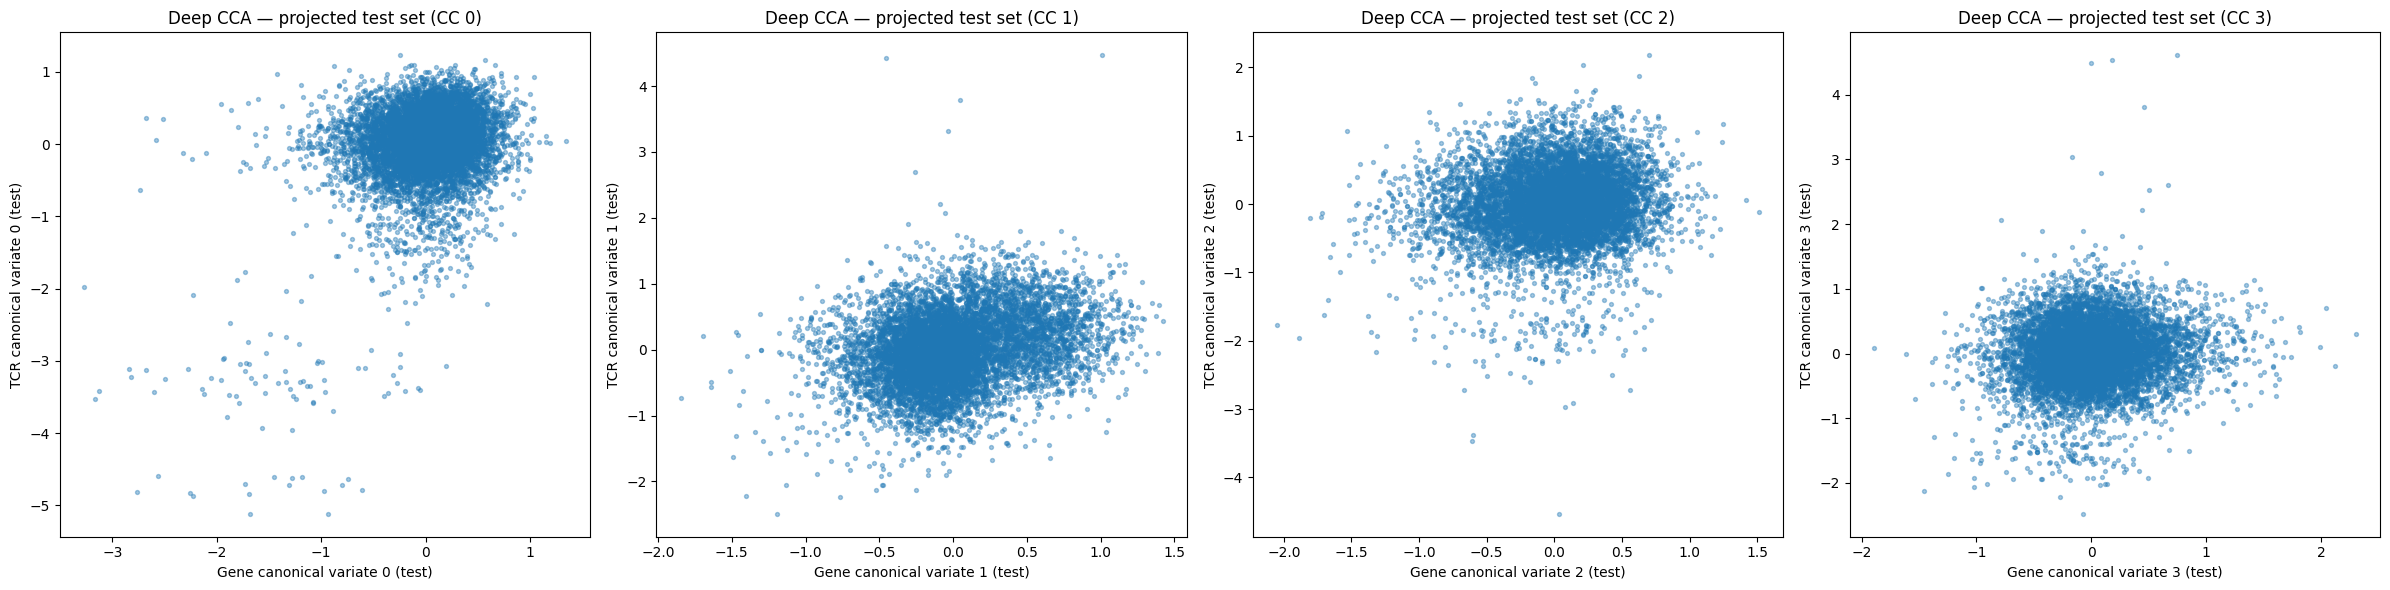

In [19]:
fig, axes = plt.subplots(1, dim_cca, figsize=(6 * dim_cca, 6))
if dim_cca == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.scatter(
        view_gene_c_test[:, i], view_tcr_c_test[:, i],
        alpha=0.4, s=8,
    )
    ax.set_xlabel(f'Gene canonical variate {i} (test)')
    ax.set_ylabel(f'TCR canonical variate {i} (test)')
    ax.set_title(f'Deep CCA — projected test set (CC {i})')

plt.tight_layout()
plt.show()

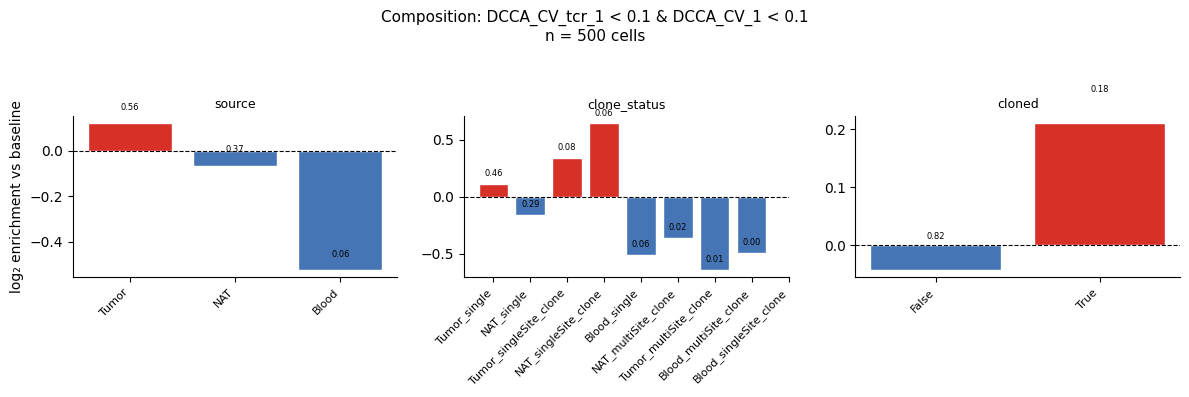


--- source ---
          n  fraction
source               
Tumor   281     0.562
NAT     187     0.374
Blood    32     0.064

--- clone_status ---
                          n  fraction
clone_status                         
Tumor_single            232     0.464
NAT_single              146     0.292
Tumor_singleSite_clone   42     0.084
NAT_singleSite_clone     31     0.062
Blood_single             31     0.062
NAT_multiSite_clone      10     0.020
Tumor_multiSite_clone     7     0.014
Blood_multiSite_clone     1     0.002
Blood_singleSite_clone    0     0.000

--- cloned ---
          n  fraction
cloned               
False   409     0.818
True     91     0.182


In [20]:
cca_k = 2
mask = (
    (mdata['gex'].obs['DCCA_CV_TCR_' + str(cca_k)] < -1.5) &
    (mdata['gex'].obs['DCCA_CV_' + str(cca_k)]     < 1.5)
)

mdata_sub = mdata[mask].copy()


composition_cols = ['source', 'clone_status', 'cloned']

fig, axes = plt.subplots(1, len(composition_cols),
                          figsize=(4 * len(composition_cols), 4))

for ax, c in zip(axes, composition_cols):
    if c not in mdata_sub.obs.columns:
        ax.set_visible(False)
        continue

    freq     = mdata_sub.obs[c].value_counts(normalize=True).sort_values(ascending=False)
    baseline = mdata.obs[c].value_counts(normalize=True).reindex(freq.index, fill_value=1e-9)

    log2_enrich = np.log2(freq / baseline)

    colors = ['#d73027' if v > 0 else '#4575b4' for v in log2_enrich]

    ax.bar(range(len(freq)), log2_enrich.values, color=colors, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(range(len(freq)))
    ax.set_xticklabels(freq.index, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('log₂ enrichment vs baseline' if ax == axes[0] else '')
    ax.set_title(c, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

    # annotate raw fraction on each bar
    for j, (cat, frac) in enumerate(freq.items()):
        ax.text(j, log2_enrich[cat] + 0.05, f'{frac:.2f}',
                ha='center', va='bottom', fontsize=6)

plt.suptitle(
    f'Composition: DCCA_CV_tcr_1 < 0.1 & DCCA_CV_1 < 0.1\n'
    f'n = {mask.sum()} cells',
    fontsize=11
)
plt.tight_layout()
plt.savefig('mdata_sub_composition.pdf', bbox_inches='tight')
plt.show()

# also print raw counts and fractions
for c in composition_cols:
    if c not in mdata_sub.obs.columns:
        continue
    print(f'\n--- {c} ---')
    counts = mdata_sub.obs[c].value_counts()
    frac   = mdata_sub.obs[c].value_counts(normalize=True)
    print(pd.DataFrame({'n': counts, 'fraction': frac.round(3)}))

In [21]:
mdata

MuData object with n_obs × n_vars = 28002 × 2551
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned', 'in_two_tissue', 'clone_status', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length', 'set'
  uns:	'hvg_union_COMBAT_ID_meta', 'tcr_embs_feature_names'
  obsm:	'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call', 'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	28002 x 2551
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'patient', 'source', 'type', 'subtype', 'clone_status', 'DCCA_CV_0', 'DCCA_CV_TCR_0', 'DCCA_CV_1', 'DCCA_CV_TCR_1', 'DCCA_CV_2', 'DCCA_CV_TCR_2', 'DCCA_CV_3', 'DCCA_CV_TCR_3', 'CV_score_0', 'CV_score_1', 'CV_score_2', 'CV_score_3'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'hvg_union_COMBAT_ID', 'mean', 'std'
      uns:	'X_umap_harmony', 'hvg_union_COMBAT_ID_k200', 'hvg_union_COMBAT_ID_meta', 'log1p', 'neighbors', 'neighbors_harmony', 'patient_colors', 'pca', 'source_colors', 'subtype_colors', 'type_colors', 'umap', 'clone_status_colors'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'
    airr:	28002 x 0
      obs:	'sample', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'cc_aa_tcrdist', 'chain_indices', 'clone_id', 'ir_dist_aa_identity', 'ir_dist_aa_tcrdist', 'ir_dist_nt_identity'
      obsm:	'airr', 'chain_indices'

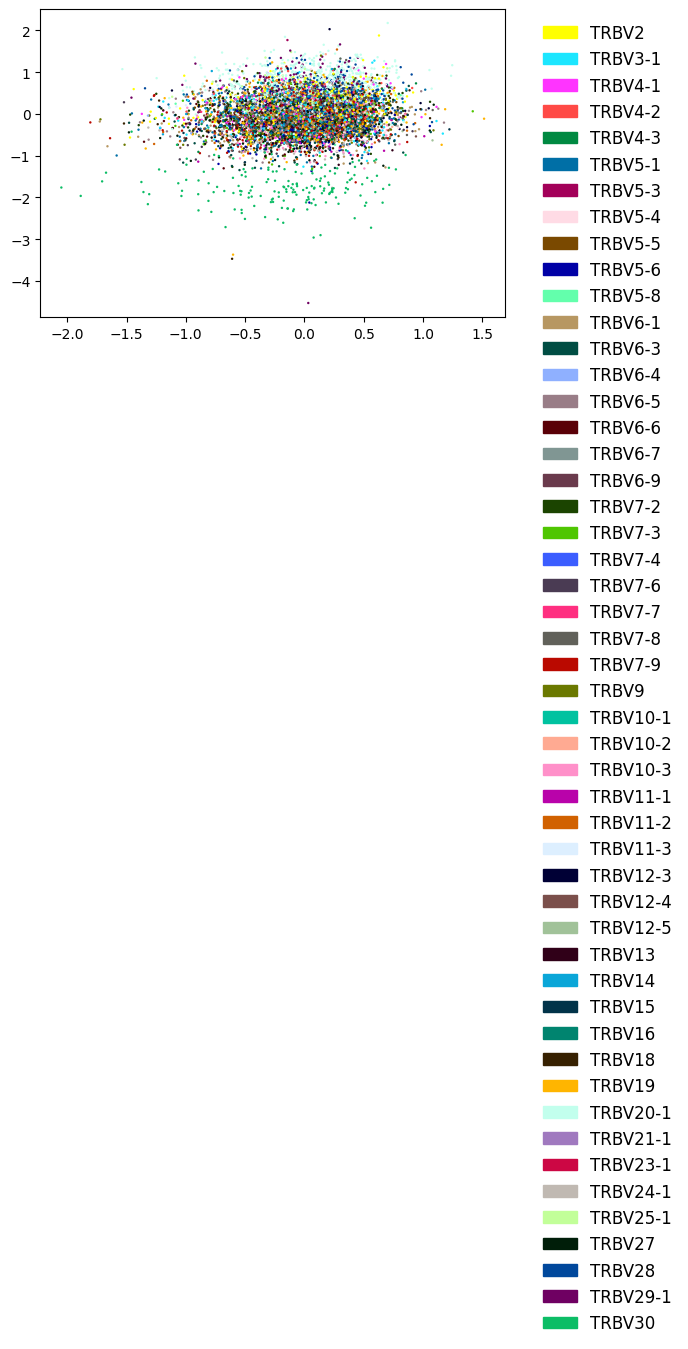

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# Get categories and assign colors
# Annotation_minor_subset
obs_select = 'VDJ_1_v_call'
# cats = mdata['gex'].obs[obs_select][test_mask].cat.categories
# palette = dict(zip(cats, sc.pl.palettes.default_102[:len(cats)]))
# colors = mdata['gex'].obs[obs_select][test_mask].map(palette)

cats = mdata.obs[obs_select][test_mask].cat.categories
palette = dict(zip(cats, sc.pl.palettes.default_102[:len(cats)]))
colors = mdata.obs[obs_select][test_mask].map(palette)


# Get UMAP coordinates
fig, ax = plt.subplots(figsize=(6,4))

i = 2
ax.scatter(
    view_gene_c_test[:, i], view_tcr_c_test[:, i],
    c=colors,
    linewidths=0,
    s = 3
)

# Legend
handles = [mpatches.Patch(color=palette[cat], label=cat) for cat in cats]
ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, frameon=False)

plt.tight_layout()
plt.show()

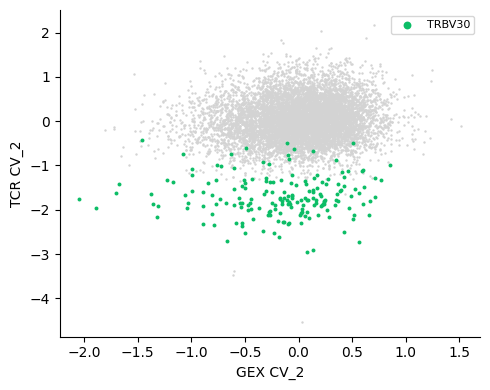

In [23]:
obs_select = 'VDJ_1_v_call'
cats = mdata.obs[obs_select][test_mask].cat.categories
palette = dict(zip(cats, sc.pl.palettes.default_102[:len(cats)]))

target = 'TRBV30'
labels = mdata.obs[obs_select][test_mask]

# gray for all, highlight color for target
colors = labels.map(lambda x: palette.get(target, 'red') if x == target else '#d3d3d3')

fig, ax = plt.subplots(figsize=(5, 4))
i = 2

# plot gray background first
bg_mask = labels != target
ax.scatter(
    view_gene_c_test[bg_mask, i], view_tcr_c_test[bg_mask, i],
    c='#d3d3d3', linewidths=0, s=3, zorder=1
)

# plot highlight on top
fg_mask = labels == target
ax.scatter(
    view_gene_c_test[fg_mask, i], view_tcr_c_test[fg_mask, i],
    c=palette.get(target, 'red'), linewidths=0, s=8,
    zorder=2, label=target
)

ax.set_xlabel(f'GEX CV_{i}')
ax.set_ylabel(f'TCR CV_{i}')
ax.legend(fontsize=8, markerscale=2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [38]:
## DEG for these

target_gene  = 'TRBV30'
v_call_col   = 'VDJ_1_v_call'
subtype_col  = 'subtype'

# work on gex modality
adata = mdata['gex'].copy()
adata.obs[v_call_col] = mdata.obs[v_call_col]

# only use test set cells
adata = adata[test_mask].copy()

results = {}

for st in adata.obs[subtype_col].dropna().unique():

    # cells of this subtype
    st_mask   = adata.obs[subtype_col] == st

    # within subtype: TRBV30 vs rest
    trbv_mask = (adata.obs[v_call_col] == target_gene) & st_mask
    rest_mask = (adata.obs[v_call_col] != target_gene) & st_mask

    n_trbv = trbv_mask.sum()
    n_rest = rest_mask.sum()

    if n_trbv < 3 or n_rest < 3:
        print(f'Skipping {st}: TRBV30 n={n_trbv}, rest n={n_rest}')
        continue

    print(f'Running DEG for {st}: TRBV30 n={n_trbv} vs rest n={n_rest}')

    # label group
    adata.obs['deg_group'] = 'skip'
    adata.obs.loc[trbv_mask, 'deg_group'] = 'TRBV30'
    adata.obs.loc[rest_mask, 'deg_group'] = 'rest'

    # subset to just these two groups
    sub = adata[adata.obs['deg_group'] != 'skip'].copy()

    sc.tl.rank_genes_groups(
        sub,
        groupby    = 'deg_group',
        groups     = ['TRBV30'],
        reference  = 'rest',
        method     = 'wilcoxon',
        key_added  = 'deg_trbv30',
        pts        = True,
    )

    # extract results
    deg_df = sc.get.rank_genes_groups_df(
        sub,
        group   = 'TRBV30',
        key     = 'deg_trbv30',
        pval_cutoff  = 0.1,
    ).assign(subtype=st)

    results[st] = deg_df

# concatenate all subtypes
df_deg = pd.concat(results.values(), ignore_index=True)
df_deg = df_deg.sort_values(['subtype', 'pvals_adj'])

df_deg.head()

Skipping CD8_Teff: TRBV30 n=2, rest n=263
Running DEG for CD4_Trm: TRBV30 n=21 vs rest n=742
Running DEG for CD4_FOS: TRBV30 n=33 vs rest n=1172
Running DEG for CD4_TCF7: TRBV30 n=34 vs rest n=1871
Running DEG for CD8_Trm_exh_L: TRBV30 n=12 vs rest n=529
Running DEG for CD8_Trm_exh_H: TRBV30 n=5 vs rest n=262
Running DEG for CD8_Tem: TRBV30 n=10 vs rest n=555
Running DEG for CD4_IL6ST: TRBV30 n=7 vs rest n=496
Running DEG for CD8_Trm_exh_M: TRBV30 n=4 vs rest n=180
Running DEG for CD4_Treg: TRBV30 n=23 vs rest n=1018
Running DEG for CD4_RPL32: TRBV30 n=16 vs rest n=506
Skipping CD8_Mitosis: TRBV30 n=1, rest n=80
Running DEG for CD8_KLRB1: TRBV30 n=4 vs rest n=129
Skipping CD8_Chrom: TRBV30 n=1, rest n=93
Running DEG for others_MT: TRBV30 n=7 vs rest n=291
Skipping others_nan: TRBV30 n=0, rest n=7


,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,subtype
0,EPHB6,5.06216,9.555114,4.145337e-07,0.001057,1.0,1.0,CD4_Treg


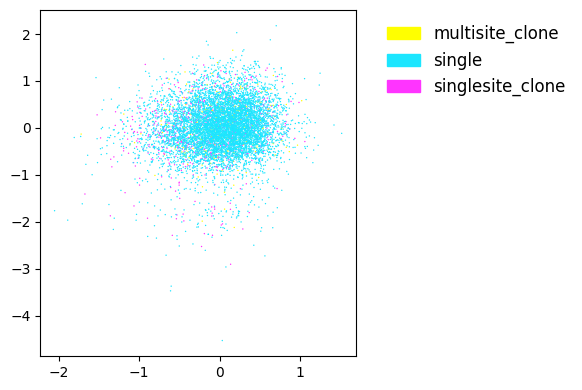

In [40]:
import numpy as np

# Convert to string temporarily to ensure string methods work
obs_select = 'clone_status'
obs_col = mdata['gex'].obs[obs_select].astype(str)

# Define the matching conditions
conditions = [
    obs_col.str.endswith('multiSite_clone'),
    obs_col.str.endswith('singleSite_clone'),
    obs_col.str.endswith('single')
]

# Define what those conditions should map to
choices = [
    'multisite_clone', 
    'singlesite_clone', 
    'single'
]

# Apply the mapping (defaulting to 'other' if no match is found)
mdata['gex'].obs['T_set'] = np.select(conditions, choices, default='other')
# Convert back to categorical for Scanpy/MuData memory efficiency
mdata['gex'].obs['T_set'] = mdata['gex'].obs['T_set'].astype('category')

cats = mdata['gex'].obs['T_set'][test_mask].cat.categories
palette = dict(zip(cats, sc.pl.palettes.default_102[:len(cats)]))
colors = mdata['gex'].obs['T_set'][test_mask].map(palette)

# Get UMAP coordinates
fig, ax = plt.subplots(figsize=(6,4))

i = 2
ax.scatter(
    view_gene_c_test[:, i], view_tcr_c_test[:, i],
    c=colors,
    linewidths=0,
    s = 1
)

# Legend
handles = [mpatches.Patch(color=palette[cat], label=cat) for cat in cats]
ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, frameon=False)

plt.tight_layout()
plt.show()


=== Count ===
subtype           CD4_FOS  CD4_IL6ST  CD4_RPL32  CD4_TCF7  CD4_Treg  CD4_Trm  \
T_set                                                                          
multisite_clone       127         21         29       102        74      135   
single               3796       1506       1632      6025      2864     2022   
singlesite_clone      250        169         88       150       474      438   
Total                4173       1696       1749      6277      3412     2595   

subtype           CD8_Chrom  CD8_KLRB1  CD8_Mitosis  CD8_Teff  CD8_Tem  \
T_set                                                                    
multisite_clone          27         37           11       135      221   
single                  242        372          203       489     1319   
singlesite_clone         23         31           64       150      309   
Total                   292        440          278       774     1849   

subtype           CD8_Trm_exh_H  CD8_Trm_exh_L  CD8_Trm_exh_

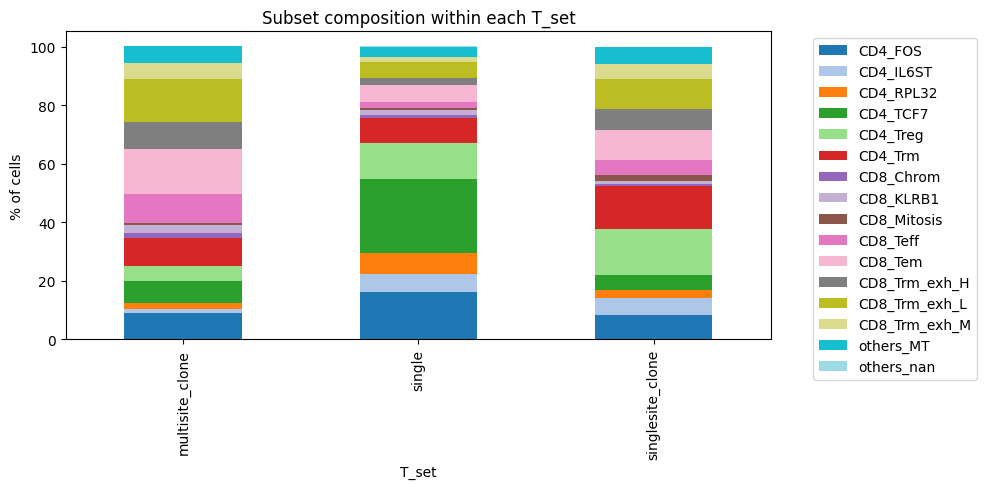

In [43]:
import pandas as pd

# Cross-tabulation of subset composition within each T_set
crosstab = pd.crosstab(
    mdata['gex'].obs['T_set'],
    mdata['gex'].obs['subtype'],
    margins=True,
    margins_name='Total'
)

# Normalized by row (proportion within each T_set)
crosstab_pct = pd.crosstab(
    mdata['gex'].obs['T_set'],
    mdata['gex'].obs['subtype'],
    normalize='index'
).round(3) * 100

print("=== Count ===")
print(crosstab)
print("\n=== % within T_set ===")
print(crosstab_pct)


crosstab_pct.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='tab20')
plt.ylabel('% of cells')
plt.xlabel('T_set')
plt.title('Subset composition within each T_set')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [46]:
corr_train, corr_test = TCR_embedings.train_test_corr(view_gene_c_train, view_tcr_c_train, view_gene_c_test, view_tcr_c_test)

Canonical Correlations Comparison:
Component       Train Corr      Test Corr       Difference     
Component 1      0.3502          0.3095          0.0408         
Component 2      0.2988          0.2785          0.0203         
Component 3      0.1658          0.1085          0.0572         
Component 4      0.1691          0.0837          0.0854         


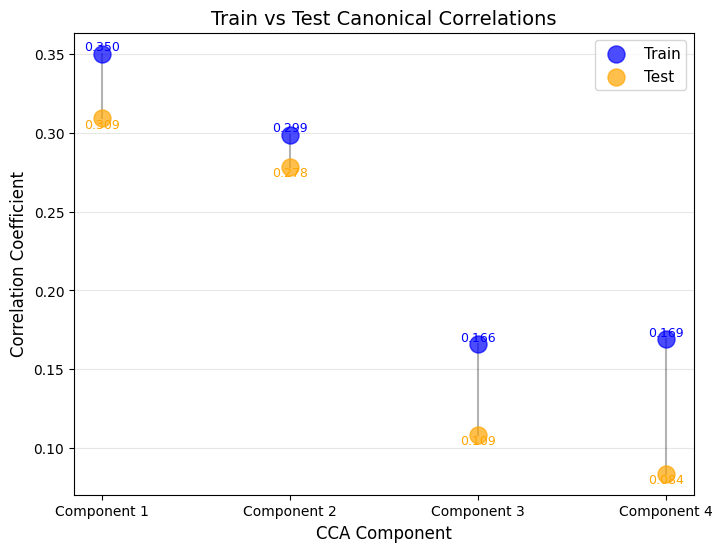

In [47]:
ax = TCR_embedings.plot_train_test_corr(corr_train, corr_test)
# ax.set_ylim(0, 1)

In [48]:
# mdata['gex'].obs['Annotation_minor_subset'] = (
#     mdata['gex'].obs['Annotation_minor_subset']
#     .cat.remove_unused_categories()
# )

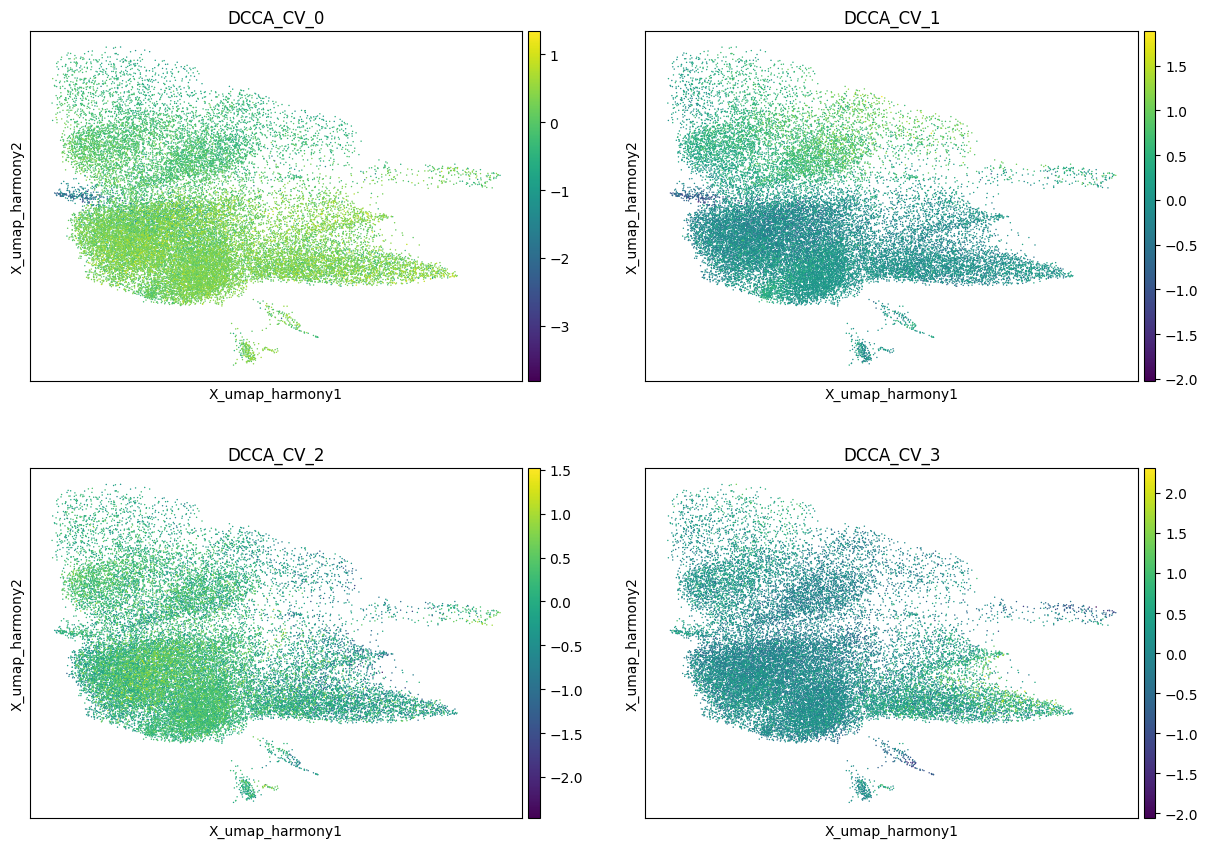

In [49]:
cols = [c for c in (
    'DCCA_CV_0',
    'DCCA_CV_1',
    'DCCA_CV_2',
    'DCCA_CV_3',
    
) if c in mdata['gex'].obs]

sc.pl.embedding(mdata['gex'], basis = 'X_umap_harmony', neighbors_key = 'neighbors_harmony', 
                color=cols, ncols=2)

### Align CCA score with obs

In [50]:
mdata

MuData object with n_obs × n_vars = 28002 × 2551
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned', 'in_two_tissue', 'clone_status', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length', 'set'
  uns:	'hvg_union_COMBAT_ID_meta', 'tcr_embs_feature_names'
  obsm:	'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call', 'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	28002 x 2551
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'patient', 'source', 'type', 'subtype', 'clone_status', 'DCCA_CV_0', 'DCCA_CV_TCR_0', 'DCCA_CV_1', 'DCCA_CV_TCR_1', 'DCCA_CV_2', 'DCCA_CV_TCR_2', 'DCCA_CV_3', 'DCCA_CV_TCR_3', 'CV_score_0', 'CV_score_1', 'CV_score_2', 'CV_score_3', 'T_set'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'hvg_union_COMBAT_ID', 'mean', 'std'
      uns:	'X_umap_harmony', 'hvg_union_COMBAT_ID_k200', 'hvg_union_COMBAT_ID_meta', 'log1p', 'neighbors', 'neighbors_harmony', 'patient_colors', 'pca', 'source_colors', 'subtype_colors', 'type_colors', 'umap', 'clone_status_colors'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'
    airr:	28002 x 0
      obs:	'sample', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'cc_aa_tcrdist', 'chain_indices', 'clone_id', 'ir_dist_aa_identity', 'ir_dist_aa_tcrdist', 'ir_dist_nt_identity'
      obsm:	'airr', 'chain_indices'

In [51]:
# Step 1 — Kruskal-Wallis / Point-biserial: does this column matter at all?

from scipy.stats import kruskal, pointbiserialr
import pandas as pd

composition_cols = ['type', 'subtype', 'in_two_tissue', 'clone_status', 'cloned', 'source']
for obs in composition_cols:
    mdata['gex'].obs[obs] = mdata.obs[obs]
    
records = []
# CV_from = "DCCA_CV_"
CV_from = "DCCA_CV_TCR_"


for i in range(dim_cca):
    col = CV_from + str(i)
    scores = mdata['gex'].obs[col].dropna()
    idx = scores.index

    for c in composition_cols:
        cats = mdata.obs.loc[idx, c].dropna()
        shared_idx = scores.index.intersection(cats.index)
        s = scores.loc[shared_idx]
        g = cats.loc[shared_idx]

        unique_cats = g.unique()

        if len(unique_cats) == 2:
            # binary → point-biserial r
            binary = (g == unique_cats[0]).astype(int)
            r, p = pointbiserialr(binary, s)
            records.append(dict(cv=col, obs_col=c, test='pointbiserial',
                                statistic=r, pval=p, categories=list(unique_cats)))

        elif len(unique_cats) > 2:
            # multi-category → Kruskal-Wallis H
            groups = [s[g == cat].values for cat in unique_cats]
            groups = [g for g in groups if len(g) > 1]
            if len(groups) >= 2:
                H, p = kruskal(*groups)
                records.append(dict(cv=col, obs_col=c, test='kruskal',
                                    statistic=H, pval=p, categories=list(unique_cats)))

df_stats = pd.DataFrame(records)

# FDR correction
from statsmodels.stats.multitest import multipletests
_, df_stats['pval_fdr'], _, _ = multipletests(df_stats['pval'], method='fdr_bh')
df_stats = df_stats.sort_values(['cv', 'pval_fdr'])
print(df_stats[['cv', 'obs_col', 'test', 'statistic', 'pval', 'pval_fdr']])

               cv        obs_col           test    statistic           pval  \
1   DCCA_CV_TCR_0        subtype        kruskal   960.110199  4.752111e-195   
0   DCCA_CV_TCR_0           type        kruskal   891.426930  2.685972e-194   
3   DCCA_CV_TCR_0   clone_status        kruskal   102.871687   1.103850e-18   
4   DCCA_CV_TCR_0         cloned  pointbiserial    -0.042723   8.539279e-13   
2   DCCA_CV_TCR_0  in_two_tissue  pointbiserial     0.033022   3.256280e-08   
5   DCCA_CV_TCR_0         source        kruskal    21.748791   1.893695e-05   
7   DCCA_CV_TCR_1        subtype        kruskal  1490.957005  4.418690e-309   
6   DCCA_CV_TCR_1           type        kruskal  1198.229767  6.422617e-261   
9   DCCA_CV_TCR_1   clone_status        kruskal   153.815413   3.134830e-29   
10  DCCA_CV_TCR_1         cloned  pointbiserial     0.065424   5.999664e-28   
8   DCCA_CV_TCR_1  in_two_tissue  pointbiserial    -0.038078   1.841753e-10   
11  DCCA_CV_TCR_1         source        kruskal    1

In [52]:
# Step 2 — Spearman per category label: which specific label drives it?
from scipy.stats import spearmanr

records_cat = []

for i in range(3):
    col = CV_from + str(i)
    scores = mdata['gex'].obs[col].dropna()

    for c in composition_cols:
        cats = mdata.obs.loc[scores.index, c].dropna()
        shared = scores.index.intersection(cats.index)

        for cat_val in cats.loc[shared].unique():
            binary = (cats.loc[shared] == cat_val).astype(int)
            r, p = spearmanr(scores.loc[shared], binary)
            records_cat.append(dict(cv=col, obs_col=c, category=cat_val,
                                    spearman_r=r, pval=p))

df_cat = pd.DataFrame(records_cat)
_, df_cat['pval_fdr'], _, _ = multipletests(df_cat['pval'], method='fdr_bh')
df_cat = df_cat.sort_values('spearman_r', key=abs, ascending=False)
print(df_cat.head(20))

               cv  obs_col       category  spearman_r           pval  \
35  DCCA_CV_TCR_1     type            CD4   -0.202150  4.907272e-256   
36  DCCA_CV_TCR_1     type            CD8    0.201889  2.297330e-255   
1   DCCA_CV_TCR_0     type            CD8   -0.175884  2.351298e-193   
0   DCCA_CV_TCR_0     type            CD4    0.172213  2.481581e-185   
42  DCCA_CV_TCR_1  subtype  CD8_Trm_exh_L    0.106475   2.116381e-71   
47  DCCA_CV_TCR_1  subtype        CD8_Tem    0.095499   9.797163e-58   
7   DCCA_CV_TCR_0  subtype  CD8_Trm_exh_L   -0.087595   7.981176e-49   
49  DCCA_CV_TCR_1  subtype  CD8_Trm_exh_M    0.086776   6.040882e-48   
46  DCCA_CV_TCR_1  subtype  CD8_Trm_exh_H    0.086056   3.522872e-47   
41  DCCA_CV_TCR_1  subtype       CD4_TCF7   -0.069515   2.402216e-31   
12  DCCA_CV_TCR_0  subtype        CD8_Tem   -0.068502   1.742264e-30   
8   DCCA_CV_TCR_0  subtype      CD8_KLRB1   -0.066864   4.035374e-29   
66  DCCA_CV_TCR_1   cloned          False   -0.066675   5.773772

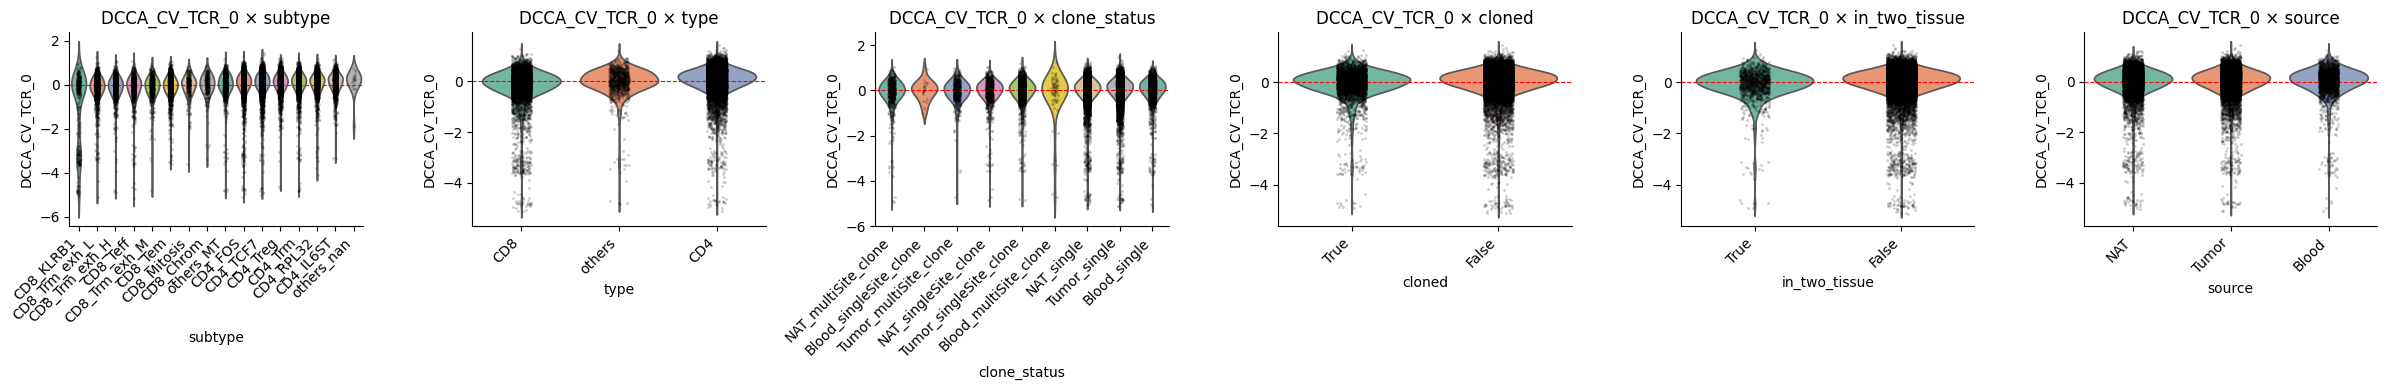

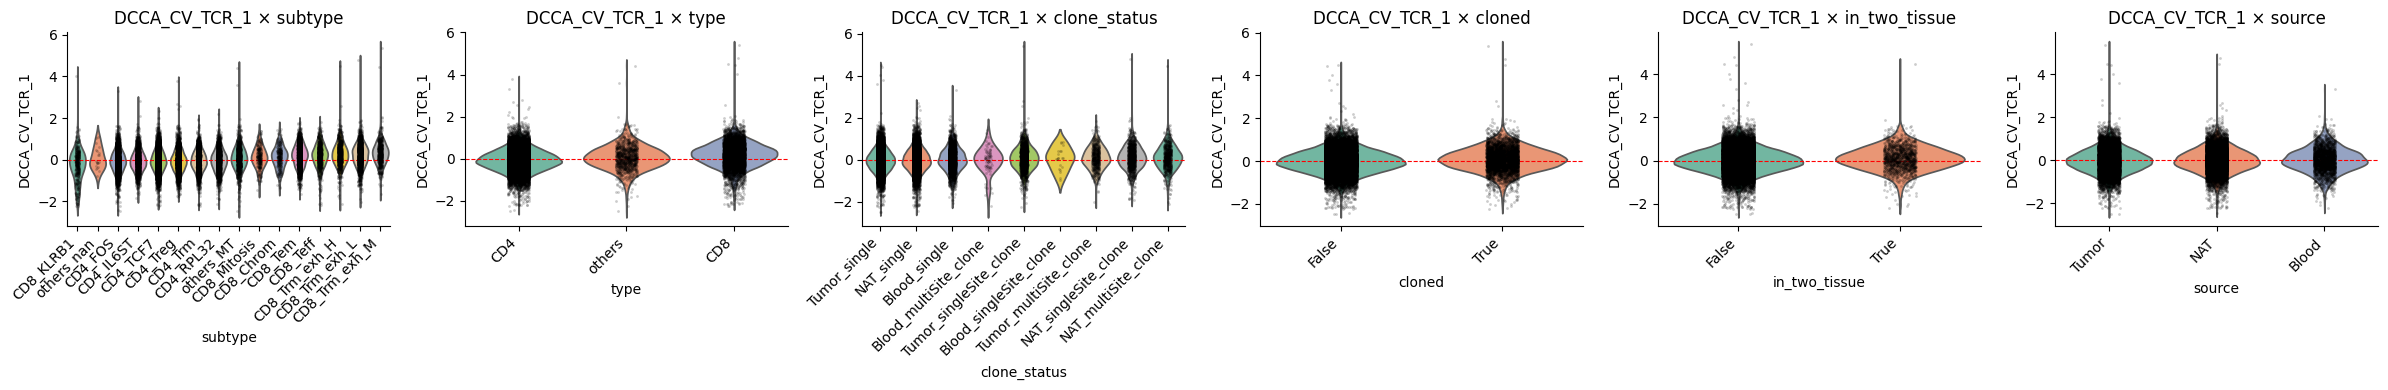

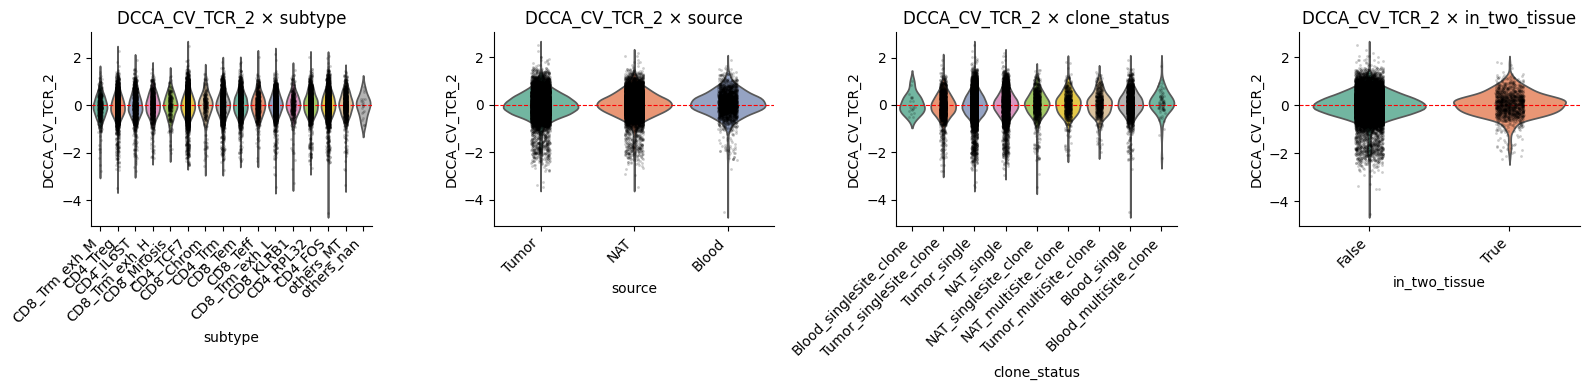

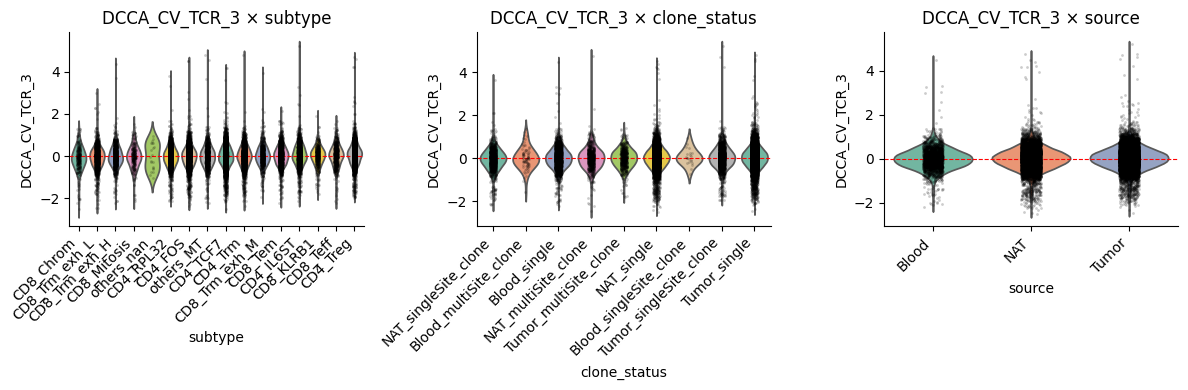

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# pick significant columns per CV from df_stats
sig = df_stats[df_stats['pval_fdr'] < 0.05]

for i in range(dim_cca):
    col = CV_from + str(i)
    sig_cols = sig[sig['cv'] == col]['obs_col'].tolist()

    if not sig_cols:
        continue

    fig, axes = plt.subplots(1, len(sig_cols), figsize=(4 * len(sig_cols), 4))
    if len(sig_cols) == 1:
        axes = [axes]

    for ax, c in zip(axes, sig_cols):
        mdata['gex'].obs[c] = mdata['gex'].obs[c].astype('category').cat.remove_unused_categories()
        plot_df = mdata['gex'].obs[[col, c]].dropna()
        order = plot_df.groupby(c)[col].median().sort_values().index

        sns.violinplot(data=plot_df, x=c, y=col, order=order,
                       inner=None, palette='Set2', ax=ax)
        sns.stripplot(data=plot_df, x=c, y=col, order=order,
                      color='black', alpha=0.2, size=2, ax=ax)
        ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
        ax.set_title(f'{col} × {c}')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.spines[['top', 'right']].set_visible(False)
        # ax.set_ylim([-0.5, 0.5])

    plt.tight_layout()
    plt.savefig(f'{col}_category_association.pdf', bbox_inches='tight')
    plt.show()

In [55]:
## pairwise subset comparison
from scipy.stats import mannwhitneyu
from itertools import combinations

records_posthoc = []

for i in range(dim_cca):
    col = CV_from + str(i)
    scores = mdata['gex'].obs[col].dropna()

    # only run on columns that passed Step 1 FDR
    sig_cols = df_stats[
        (df_stats['cv'] == col) & (df_stats['pval_fdr'] < 0.05)
    ]['obs_col'].tolist()

    for c in sig_cols:
        cats = mdata['gex'].obs.loc[scores.index, c].dropna()
        shared = scores.index.intersection(cats.index)
        s = scores.loc[shared]
        g = cats.loc[shared]

        unique_cats = g.unique()

        for cat_a, cat_b in combinations(unique_cats, 2):
            vals_a = s[g == cat_a].values
            vals_b = s[g == cat_b].values

            if len(vals_a) < 3 or len(vals_b) < 3:
                continue

            U, p = mannwhitneyu(vals_a, vals_b, alternative='two-sided')

            # effect size: rank-biserial correlation
            n_a, n_b = len(vals_a), len(vals_b)
            rbc = 1 - (2 * U) / (n_a * n_b)

            records_posthoc.append(dict(
                cv       = col,
                obs_col  = c,
                cat_a    = cat_a,
                cat_b    = cat_b,
                U        = U,
                pval     = p,
                rbc      = rbc,   # effect size: -1 to +1
            ))

df_posthoc = pd.DataFrame(records_posthoc)
_, df_posthoc['pval_fdr'], _, _ = multipletests(df_posthoc['pval'], method='fdr_bh')
df_posthoc = df_posthoc.sort_values('pval_fdr')
print(df_posthoc[df_posthoc['pval_fdr'] < 0.05])

                cv        obs_col          cat_a          cat_b           U  \
284  DCCA_CV_TCR_1           type            CD4            CD8  50654794.5   
120  DCCA_CV_TCR_0           type            CD4            CD8  86646587.5   
206  DCCA_CV_TCR_1        subtype       CD4_TCF7  CD8_Trm_exh_L   3901767.0   
167  DCCA_CV_TCR_1        subtype        CD4_FOS  CD8_Trm_exh_L   2543782.5   
225  DCCA_CV_TCR_1        subtype  CD8_Trm_exh_L       CD4_Treg   4038971.0   
..             ...            ...            ...            ...         ...   
11   DCCA_CV_TCR_0        subtype        CD4_FOS       CD4_Treg   6897815.0   
585  DCCA_CV_TCR_3        subtype  CD8_Trm_exh_H      CD8_Chrom    150086.0   
487  DCCA_CV_TCR_2  in_two_tissue          False           True  18100389.0   
215  DCCA_CV_TCR_1        subtype       CD4_TCF7      CD4_RPL32   5294977.5   
91   DCCA_CV_TCR_0        subtype      others_MT     others_nan      7852.0   

              pval       rbc       pval_fdr  
284  

In [56]:
# for i in range(dim_cca):
#     col = CV_from + str(i)
#     sig_cols = df_posthoc[
#         (df_posthoc['cv'] == col) & (df_posthoc['pval_fdr'] < 0.05)
#     ]['obs_col'].unique()

#     for c in sig_cols:
#         sub = df_posthoc[(df_posthoc['cv'] == col) & (df_posthoc['obs_col'] == c)]
#         cats = pd.Index(
#             pd.concat([sub['cat_a'], sub['cat_b']]).unique()
#         )

#         # pivot effect size (rbc) into a square matrix
#         mat = pd.DataFrame(np.nan, index=cats, columns=cats)
#         for _, row in sub.iterrows():
#             # mat.loc[row.cat_a, row.cat_b] = row.rbc
#             # mat.loc[row.cat_b, row.cat_a] = -row.rbc  # antisymmetric
            
#             mat.loc[row.cat_a, row.cat_b] = abs(row.rbc)
#             mat.loc[row.cat_b, row.cat_a] = abs(row.rbc)  # symmetric
            
            
#         np.fill_diagonal(mat.values, 0)

#         # significance mask
#         sig_mat = pd.DataFrame(False, index=cats, columns=cats)
#         for _, row in sub.iterrows():
#             sig = row.pval_fdr < 0.05
#             sig_mat.loc[row.cat_a, row.cat_b] = sig
#             sig_mat.loc[row.cat_b, row.cat_a] = sig

#         fig, ax = plt.subplots(figsize=(0.6 * len(cats) + 2, 0.6 * len(cats) + 2))
#         sns.heatmap(mat.astype(float), annot=True, fmt='.2f', center=0,
#                     cmap='RdBu_r', vmin= 0, vmax=1,
#                     mask=~sig_mat,         # grey out non-significant pairs
#                     linewidths=0.5, ax=ax)
#         ax.set_title(f'{col} × {c}\nrank-biserial correlation (FDR<0.05 only)', fontsize=10)
#         plt.tight_layout()
#         plt.savefig(f'{col}_{c}_posthoc_heatmap.pdf', bbox_inches='tight')
#         plt.show()

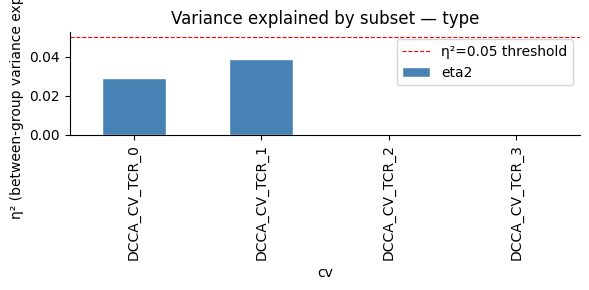

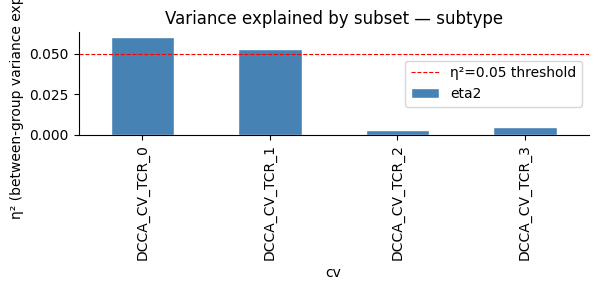

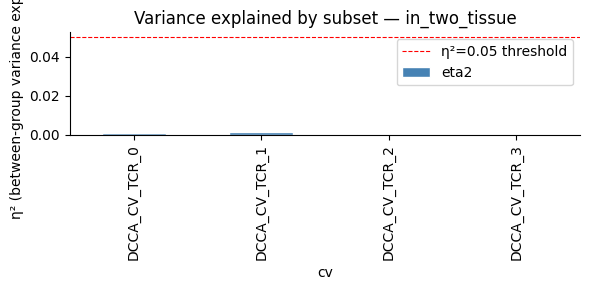

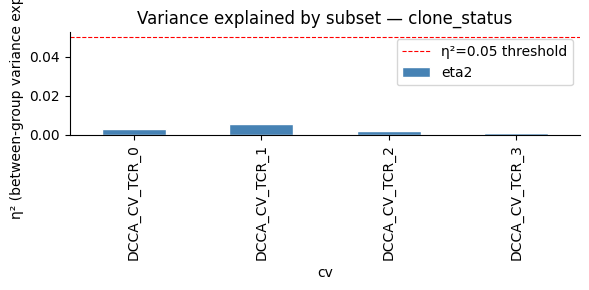

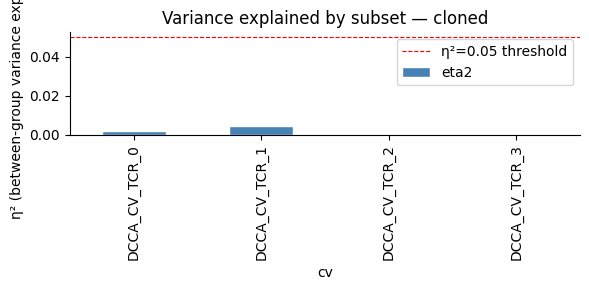

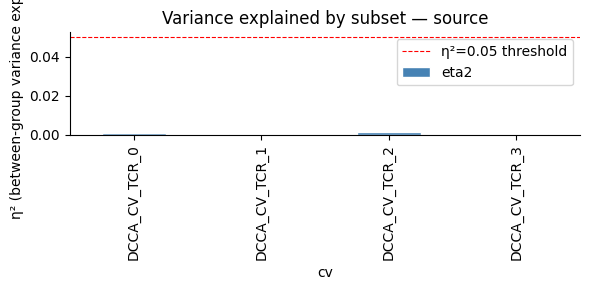

In [57]:
# 1. variance explained by each CV across subsets
#    = between-group variance / total variance per CV

records_var = []
for i in range(dim_cca):
    col = "DCCA_CV_" + str(i)
    scores = mdata['gex'].obs[col].dropna()
    total_var = scores.var()

    for c in composition_cols:
        labels = mdata['gex'].obs.loc[scores.index, c].dropna()
        shared = scores.index.intersection(labels.index)

        group_means = scores.loc[shared].groupby(labels.loc[shared]).mean()
        grand_mean  = scores.loc[shared].mean()

        # between-group variance (eta squared)
        between_var = (
            labels.loc[shared].value_counts() *
            (group_means - grand_mean) ** 2
        ).sum() / len(shared)

        eta2 = between_var / total_var

        records_var.append(dict(cv=col, obs_col=c, eta2=eta2))

df_var = pd.DataFrame(records_var)

# plot eta2 per CV per obs column
for c in composition_cols:
    sub = df_var[df_var['obs_col'] == c].set_index('cv')['eta2']
    fig, ax = plt.subplots(figsize=(6, 3))
    sub.plot.bar(ax=ax, color='steelblue', edgecolor='white')
    ax.set_ylabel('η² (between-group variance explained)')
    ax.set_title(f'Variance explained by subset — {c}')
    ax.axhline(0.05, color='red', linestyle='--', linewidth=0.8,
               label='η²=0.05 threshold')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'eta2_{c}.pdf', bbox_inches='tight')
    plt.show()

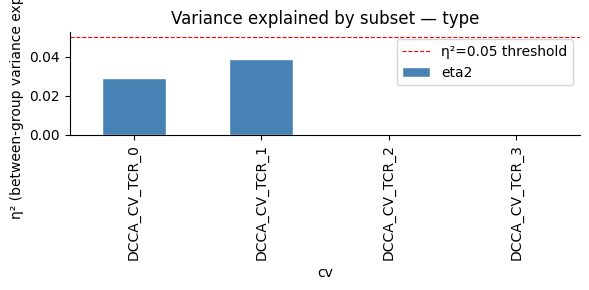

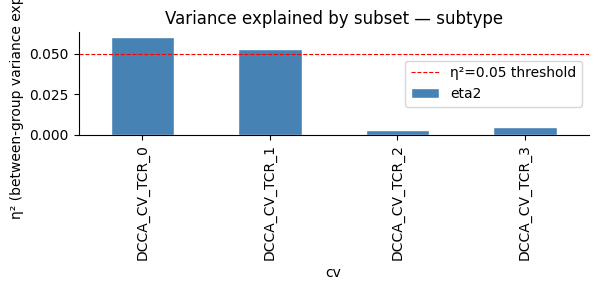

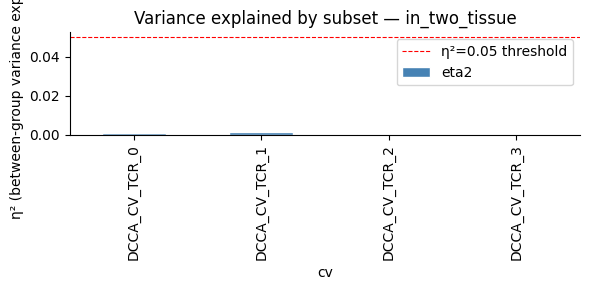

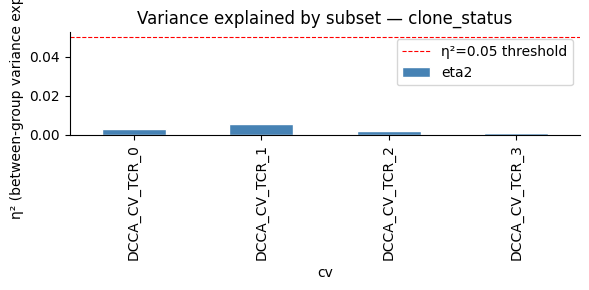

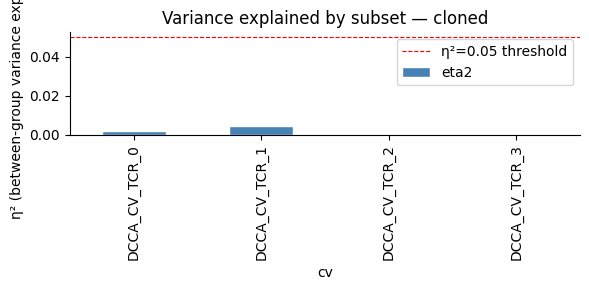

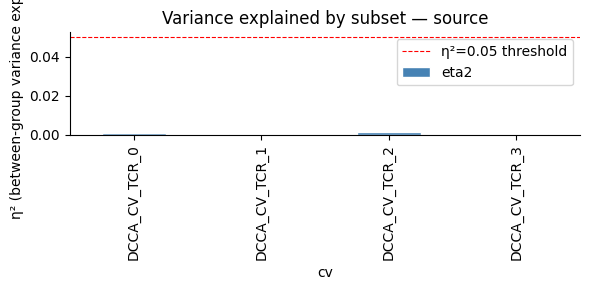

In [58]:
# 1. variance explained by each CV across subsets
#    = between-group variance / total variance per CV

records_var = []
for i in range(dim_cca):
    col = "DCCA_CV_TCR_" + str(i)
    scores = mdata['gex'].obs[col].dropna()
    total_var = scores.var()

    for c in composition_cols:
        labels = mdata['gex'].obs.loc[scores.index, c].dropna()
        shared = scores.index.intersection(labels.index)

        group_means = scores.loc[shared].groupby(labels.loc[shared]).mean()
        grand_mean  = scores.loc[shared].mean()

        # between-group variance (eta squared)
        between_var = (
            labels.loc[shared].value_counts() *
            (group_means - grand_mean) ** 2
        ).sum() / len(shared)

        eta2 = between_var / total_var

        records_var.append(dict(cv=col, obs_col=c, eta2=eta2))

df_var = pd.DataFrame(records_var)

# plot eta2 per CV per obs column
for c in composition_cols:
    sub = df_var[df_var['obs_col'] == c].set_index('cv')['eta2']
    fig, ax = plt.subplots(figsize=(6, 3))
    sub.plot.bar(ax=ax, color='steelblue', edgecolor='white')
    ax.set_ylabel('η² (between-group variance explained)')
    ax.set_title(f'Variance explained by subset — {c}')
    ax.axhline(0.05, color='red', linestyle='--', linewidth=0.8,
               label='η²=0.05 threshold')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'eta2_{c}.pdf', bbox_inches='tight')
    plt.show()

In [59]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

records_ovr = []

for i in range(dim_cca):
    col = CV_from + str(i)
    scores = mdata['gex'].obs[col].dropna()

    # only run on columns that passed Step 1 FDR
    sig_cols = df_stats[
        (df_stats['cv'] == col) & (df_stats['pval_fdr'] < 0.05)
    ]['obs_col'].tolist()

    for c in sig_cols:
        labels = mdata['gex'].obs.loc[scores.index, c].dropna()
        shared = scores.index.intersection(labels.index)
        s = scores.loc[shared]
        g = labels.loc[shared]

        for cat_val in g.unique():
            in_group  = s[g == cat_val].values
            out_group = s[g != cat_val].values  # all rest

            if len(in_group) < 3 or len(out_group) < 3:
                continue

            U, p = mannwhitneyu(in_group, out_group, alternative='two-sided')

            # rank-biserial correlation as effect size
            rbc = 1 - (2 * U) / (len(in_group) * len(out_group))

            # median difference
            median_diff = np.median(in_group) - np.median(out_group)

            records_ovr.append(dict(
                cv          = col,
                obs_col     = c,
                category    = cat_val,
                n_in        = len(in_group),
                n_out       = len(out_group),
                U           = U,
                rbc         = rbc,
                median_diff = median_diff,
                pval        = p,
            ))

df_ovr = pd.DataFrame(records_ovr)
_, df_ovr['pval_fdr'], _, _ = multipletests(df_ovr['pval'], method='fdr_bh')
df_ovr = df_ovr.sort_values(['cv', 'pval_fdr'])

print(df_ovr[df_ovr['pval_fdr'] < 0.05])

                cv  obs_col       category   n_in  n_out           U  \
17   DCCA_CV_TCR_0     type            CD8   7029  20973  56447142.5   
16   DCCA_CV_TCR_0     type            CD4  19902   8100  98277879.5   
4    DCCA_CV_TCR_0  subtype  CD8_Trm_exh_L   1798  26204  18697178.5   
9    DCCA_CV_TCR_0  subtype        CD8_Tem   1849  26153  20327824.0   
5    DCCA_CV_TCR_0  subtype      CD8_KLRB1    440  27562   4181412.0   
..             ...      ...            ...    ...    ...         ...   
100  DCCA_CV_TCR_3  subtype        CD4_FOS   4173  23829  48415798.5   
126  DCCA_CV_TCR_3   source            NAT  10953  17049  91622940.5   
113  DCCA_CV_TCR_3  subtype      CD4_RPL32   1749  26253  22204228.5   
109  DCCA_CV_TCR_3  subtype        CD8_Tem   1849  26153  24928977.0   
101  DCCA_CV_TCR_3  subtype       CD8_Teff    774  27228  11023181.5   

          rbc  median_diff           pval       pval_fdr  
17   0.234196    -0.165567  2.164371e-190  9.234650e-189  
16  -0.219282    

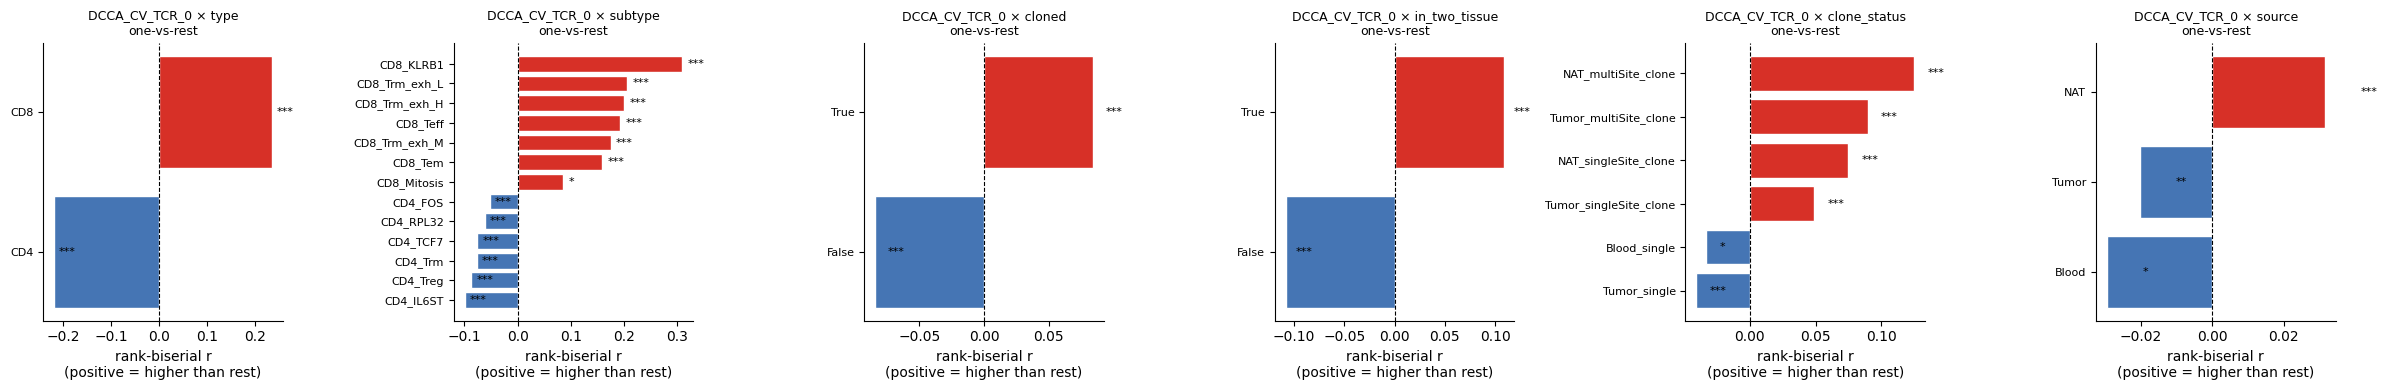

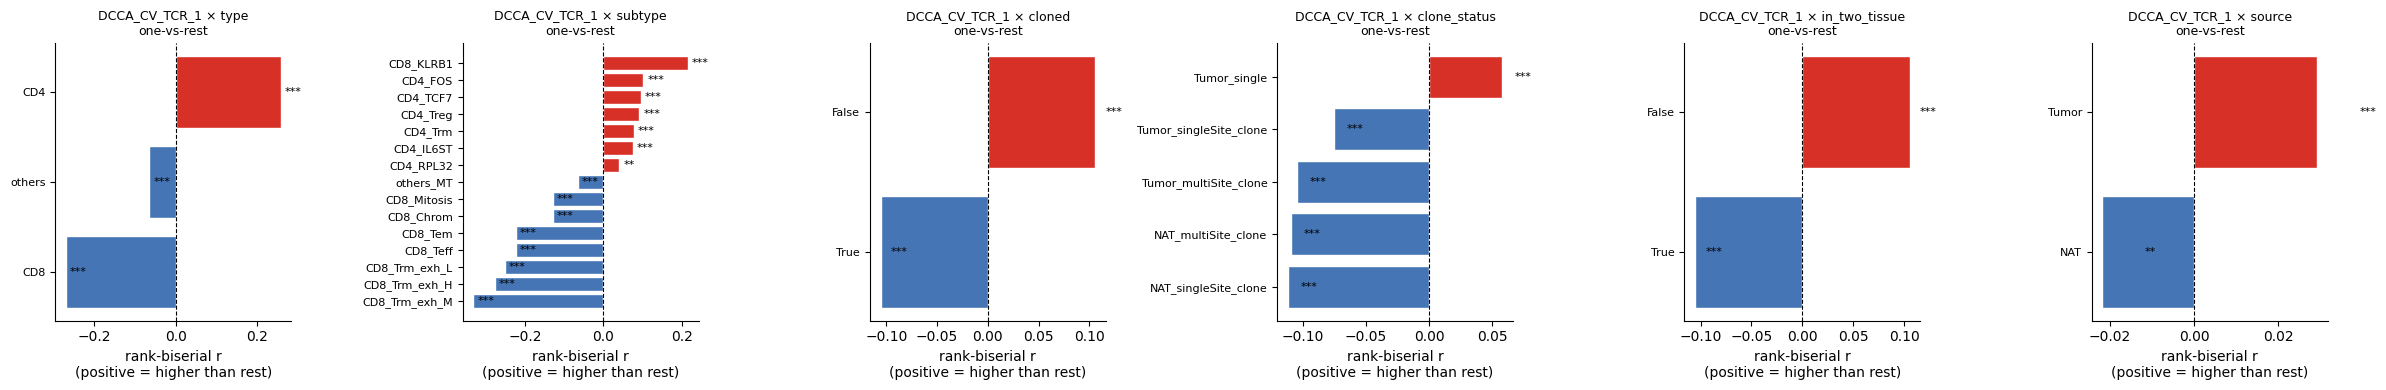

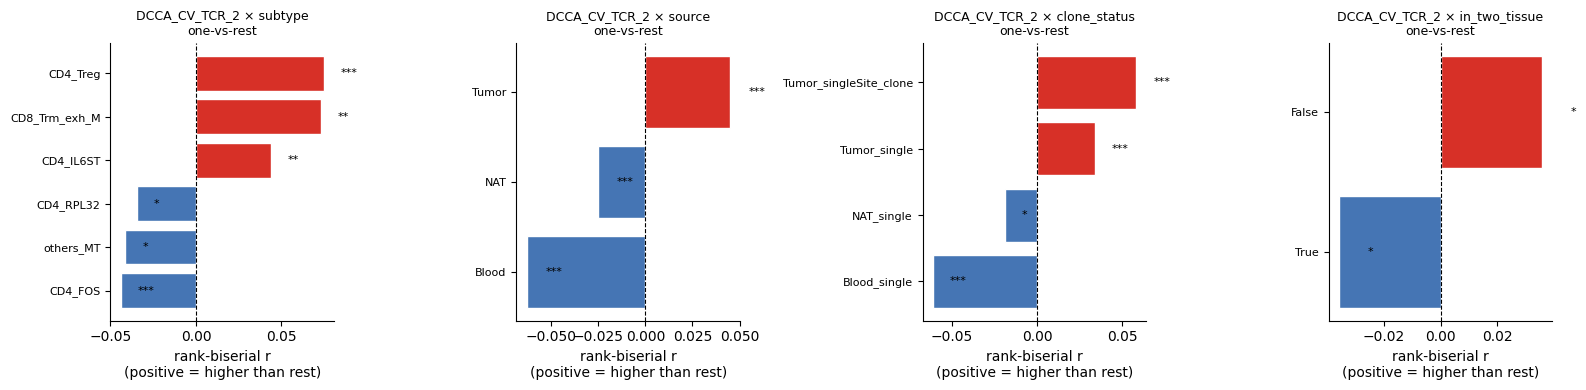

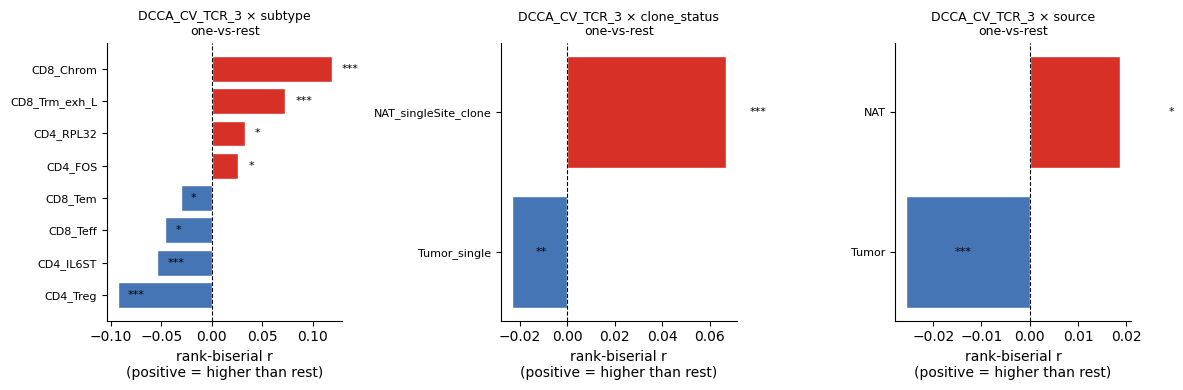

In [60]:
for i in range(dim_cca):
    col = CV_from + str(i)
    sub = df_ovr[
        (df_ovr['cv'] == col) & (df_ovr['pval_fdr'] < 0.05)
    ]

    if sub.empty:
        continue

    sig_cols = sub['obs_col'].unique()
    fig, axes = plt.subplots(1, len(sig_cols),
                              figsize=(4 * len(sig_cols), 4))
    if len(sig_cols) == 1:
        axes = [axes]

    for ax, c in zip(axes, sig_cols):
        plot_df = sub[sub['obs_col'] == c].sort_values('rbc')

        colors = ['#d73027' if v > 0 else '#4575b4'
                  for v in plot_df['rbc']]

        ax.barh(range(len(plot_df)), plot_df['rbc'],
                color=colors, edgecolor='white')
        ax.set_yticks(range(len(plot_df)))
        ax.set_yticklabels(plot_df['category'], fontsize=8)
        ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xlabel('rank-biserial r\n(positive = higher than rest)')
        ax.set_title(f'{col} × {c}\none-vs-rest', fontsize=9)

        # mark FDR significance
        for j, (_, row) in enumerate(plot_df.iterrows()):
            stars = ('***' if row.pval_fdr < 0.001 else
                     '**'  if row.pval_fdr < 0.01  else
                     '*'   if row.pval_fdr < 0.05  else '')
            ax.text(row.rbc + 0.01, j, stars, va='center', fontsize=8)

        ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{col}_ovr.pdf', bbox_inches='tight')
    plt.show()

# Quality for fusion

### Contribution scores

In [61]:
# 
# df_cca_weights = pd.DataFrame(cca.y_weights_)
# # df_cca_weights.to_csv(filename + 'TCR_weights.csv')
# cca_weights_abs = df_cca_weights.abs()

# cca_weights_abs_beta = cca_weights_abs.iloc[0:596].sum() + cca_weights_abs.iloc[1191:1128].sum()
# cca_weights_abs_alpha = cca_weights_abs.iloc[596:596+596].sum() + cca_weights_abs.iloc[1128:1374].sum()
# df_cca_weights_abs_sum = pd.DataFrame(
#     [cca_weights_abs_beta, cca_weights_abs_alpha],
#     index=['beta', 'alpha']
# )

# df_cca_weights_abs_sum = df_cca_weights_abs_sum / df_cca_weights_abs_sum.sum(axis=0)
# df_cca_weights_abs_sum


## metrics comparison between subsets in mdata

In [62]:
aa

NameError: name 'aa' is not defined

In [ ]:
# 4. Visualize — PCA of CV space colored by subset
# "Where do subsets sit in the joint CV space?"

from sklearn.decomposition import PCA

cv_matrix = mdata['gex'].obs[cv_cols].dropna()
pca = PCA(n_components=2)
embedding = pca.fit_transform(cv_matrix.values)
embed_df  = pd.DataFrame(embedding, index=cv_matrix.index,
                         columns=['PC1', 'PC2'])

for c in composition_cols:
    labels = mdata['gex'].obs.loc[cv_matrix.index, c]
    embed_df[c] = labels.values

    fig, ax = plt.subplots(figsize=(6, 5))
    for cat_val, grp in embed_df.groupby(c):
        ax.scatter(grp['PC1'], grp['PC2'], label=cat_val, alpha=0.5, s=10)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(f'CV space — colored by {c}')
    ax.legend(bbox_to_anchor=(1.05, 1), fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'cv_pca_{c}.pdf', bbox_inches='tight')
    plt.show()

In [ ]:
aa

## logit regression

In [ ]:
### Logistic Regression per subtype: predict clone_status using DCCA canonical variates ###
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from imblearn.over_sampling import RandomOverSampler
import torch
import torch.nn as nn

tg = obs_select
g1, g2 = tg[0], tg[1]

cs = obs_select.astype(str).to_numpy()
sub = mdata.obs['Annotation_minor_subset'].astype(str).to_numpy()
in_groups = np.isin(cs, tg)

y_all = (cs == g1).astype(int)

subtypes = sorted(set(sub[in_groups]))

class WeightedLogistic(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.feature_weights = nn.Parameter(torch.ones(n_features))
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        return self.linear(x * self.feature_weights).squeeze(-1)

lr_results = []

for st in subtypes:
    st_mask = sub == st
    mask_tr = train_mask & in_groups & st_mask
    mask_te = test_mask & in_groups & st_mask

    X_tr = view_tcr_c[mask_tr]
    X_te = view_tcr_c[mask_te]
    y_tr = y_all[mask_tr]
    y_te = y_all[mask_te]

    if X_tr.shape[0] < 10 or X_te.shape[0] < 4:
        continue
    if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
        continue

    ros = RandomOverSampler(random_state=42)
    X_tr_bal, y_tr_bal = ros.fit_resample(X_tr, y_tr)

    # Trainable-weight logistic
    wlr_epochs = 200
    X_tr_t = torch.tensor(X_tr_bal, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr_bal, dtype=torch.float32)
    X_te_t = torch.tensor(X_te, dtype=torch.float32)

    wlr = WeightedLogistic(X_tr_t.shape[1])
    optimizer = torch.optim.Adam(wlr.parameters(), lr=1e-2)
    loss_fn = nn.BCEWithLogitsLoss()

    wlr.train()
    for epoch in range(wlr_epochs):
        optimizer.zero_grad()
        loss_fn(wlr(X_tr_t), y_tr_t).backward()
        optimizer.step()

    wlr.eval()
    with torch.no_grad():
        y_pred_proba = torch.sigmoid(wlr(X_te_t)).numpy()
        y_pred = (y_pred_proba >= 0.5).astype(int)

    acc = accuracy_score(y_te, y_pred)
    try:
        auc = roc_auc_score(y_te, y_pred_proba)
    except ValueError:
        auc = np.nan

    learned_w = wlr.feature_weights.detach().numpy()

    lr_results.append({
        'subtype': st,
        'n_train': X_tr_bal.shape[0],
        'n_test': X_te.shape[0],
        'accuracy': acc,
        'roc_auc': auc,
        'feature_weights': learned_w.tolist(),
    })

    print(f"\n{'='*60}")
    print(f"Subtype: {st}  (train={X_tr_bal.shape[0]}, test={X_te.shape[0]})")
    print(f"{'='*60}")
    print(f"Feature weights: {learned_w}")
    print(f"Accuracy: {acc:.4f}   ROC AUC: {auc:.4f}")
    print(classification_report(y_te, y_pred, target_names=[g2, g1], zero_division=0))

lr_results_df = pd.DataFrame(lr_results)
lr_results_df
